# Vehicle Routing Problem (CVRP): Clarke-Wright Savings + 2-opt + Simulated Annealing

**The problem.** A last-mile-delivery operation has a single **depot**, 40 customer locations to visit each morning, and a fleet of identical trucks with a **capacity** of 50 units each.  Customer demand varies (1-10 units per stop).  The deliverable is a set of **routes** — each starting and ending at the depot, each respecting truck capacity — that visit every customer exactly once at minimum total distance.

This is the **Capacitated Vehicle Routing Problem (CVRP)** — NP-hard in general, but solvable to near-optimal with a sequence of well-known heuristics:

1. **TSP baseline** — solve the single-vehicle Travelling Salesman ignoring capacity.  This is the lower bound on routing cost; if vehicles were infinitely large, this is what you'd run.
2. **Clarke-Wright savings** (1964) — greedy construction heuristic.  Start with one route per customer, merge routes when the merge "saves" distance, respecting capacity.  Produces a feasible solution in milliseconds.
3. **2-opt local search** — given a starting solution, repeatedly try **2-opt swaps** (reverse a sub-segment) within each route; if the swap reduces distance, keep it.  Pure local-improvement; gets stuck in local optima.
4. **Simulated annealing** — accept *worse* moves with decreasing probability ($T$ cools over time).  Escapes the local optima that 2-opt gets trapped in.  The metaheuristic that earns its keep on instances where greedy-then-local-search underperforms.

The notebook progressively layers these — each method **starts from the previous method's solution** — so the cumulative gain at each stage is visible.

**The data.**

A **synthetic single-day instance** with 1 depot + 40 customers laid out across a 100 × 100 service area, each customer with demand 1-10 units, vehicle capacity 50, Euclidean distances.  Synthetic gives us full control: we can sweep vehicle capacity and re-solve to trace the **fleet-size vs cost** trade-off, and we can plant a mild "demand cluster" in one region to see whether the algorithms find it.

**The approach.**

1. **Instance generation** + visualisation (depot + customers, demand heatmap).
2. **Distance matrix** (Euclidean for the headline; a Manhattan-distance variant is one line away for grid-street operations).
3. **TSP baseline** via nearest-neighbour + 2-opt; the no-capacity lower bound.
4. **Clarke-Wright savings** — hand-rolled, ~50 LOC.
5. **2-opt within-route improvement** layered on top of the savings solution.
6. **Simulated annealing** with **inter-route moves** (swap a customer from route A into route B, **insert into best position**).  Accepts worsening moves with probability $\exp(-\Delta / T)$ at temperature $T$, geometric cooling.
7. **Route-map visualisation** — 2 × 2 panel: TSP, Savings, Savings+2opt, Savings+2opt+SA.  Visually striking; communicates the gain at each stage to a non-technical audience.
8. **Capacity-sensitivity sweep** — re-solve at vehicle capacity ∈ {30, 40, 50, 70, 100, ∞}; plot **fleet-size vs total-distance** Pareto.  The operations manager's decision plot.
9. **Time-window extension (VRPTW)** — add per-customer service windows; show how the savings algorithm needs a feasibility check at every merge attempt.
10. **Decision memo** — when each algorithm wins, when to call a commercial solver (Gurobi / OR-Tools), production rules.
11. **Limitations and next steps** — Manhattan distances on real road networks (OSRM), pickup-and-delivery, dynamic re-routing, electric-vehicle range constraints.

**Audience.** Last-mile / supply-chain / field-service teams, anyone whose dispatch problem is currently solved by a manager with a whiteboard, anyone who has heard "routing is just TSP" and needs the multi-vehicle generalisation.

## 0. Setup and reproducibility

Seeds fixed.  All artefacts (instance, routes, sensitivity sweeps, model card) live under `notebooks/artifacts/vrp/`.  Pure NumPy + SciPy + Matplotlib — no commercial solver, no `or-tools` dependency.

In [1]:
from __future__ import annotations

import io
import json
import math
import pathlib
import time
import warnings
from copy import deepcopy
from dataclasses import dataclass, field

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RNG_SEED = 2026
np.random.seed(RNG_SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 110
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

NB_DIR = pathlib.Path.cwd() if (pathlib.Path.cwd() / "vehicle_routing_clarke_wright_2opt.ipynb").exists() else pathlib.Path.cwd() / "notebooks"
DATA_DIR = NB_DIR / "artifacts" / "vrp"
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"NB_DIR    : {NB_DIR}")
print(f"DATA_DIR  : {DATA_DIR}")

NB_DIR    : C:\Users\diogo\work_code\ds-projects-portfolio\notebooks
DATA_DIR  : C:\Users\diogo\work_code\ds-projects-portfolio\notebooks\artifacts\vrp


## 1. Synthetic CVRP instance

40 customers in a 100 × 100 service area, depot at the centre.  Each customer has demand $\sim \text{Discrete-Uniform}\{1, \ldots, 10\}$, vehicle capacity 50.  We plant a mild **demand cluster** in the lower-right quadrant (5 customers with demand $\sim 7$-$10$) — operationally realistic and a useful diagnostic for whether the algorithm cleanly carves out a "high-demand-cluster" route.

In [2]:
@dataclass
class CVRPInstance:
    coords: np.ndarray
    demands: np.ndarray
    capacity: int
    depot_idx: int = 0


def generate_instance(n_customers: int = 40, area: int = 100, capacity: int = 50, seed: int = RNG_SEED) -> CVRPInstance:
    rng = np.random.default_rng(seed)
    n_total = n_customers + 1
    coords = np.zeros((n_total, 2))
    coords[0] = [area / 2, area / 2]
    cust_coords = rng.uniform(0, area, size=(n_customers, 2))
    cluster_idx = rng.choice(n_customers, size=5, replace=False)
    cust_coords[cluster_idx] = rng.normal([area * 0.75, area * 0.25], 5, size=(5, 2))
    cust_coords = np.clip(cust_coords, 1, area - 1)
    coords[1:] = cust_coords

    demands = np.zeros(n_total, dtype=int)
    demands[1:] = rng.integers(1, 11, size=n_customers)
    demands[1 + cluster_idx] = rng.integers(7, 11, size=5)
    return CVRPInstance(coords=coords, demands=demands, capacity=capacity)


INSTANCE = generate_instance(n_customers=40, capacity=50)
print(f"Customers              : {len(INSTANCE.coords) - 1}")
print(f"Vehicle capacity       : {INSTANCE.capacity}")
print(f"Total demand           : {INSTANCE.demands.sum()}")
print(f"Min vehicles required  : {math.ceil(INSTANCE.demands.sum() / INSTANCE.capacity)}")
print(f"Demand stats           : mean {INSTANCE.demands[1:].mean():.2f}, max {INSTANCE.demands[1:].max()}")

Customers              : 40
Vehicle capacity       : 50
Total demand           : 228
Min vehicles required  : 5
Demand stats           : mean 5.70, max 10


In [3]:
def euclidean_distance_matrix(coords: np.ndarray) -> np.ndarray:
    diff = coords[:, None, :] - coords[None, :, :]
    return np.sqrt((diff * diff).sum(axis=-1))


D = euclidean_distance_matrix(INSTANCE.coords)
print(f"Distance matrix shape: {D.shape}")
print(f"Mean inter-node distance: {D[D > 0].mean():.2f}")

Distance matrix shape: (41, 41)
Mean inter-node distance: 46.67


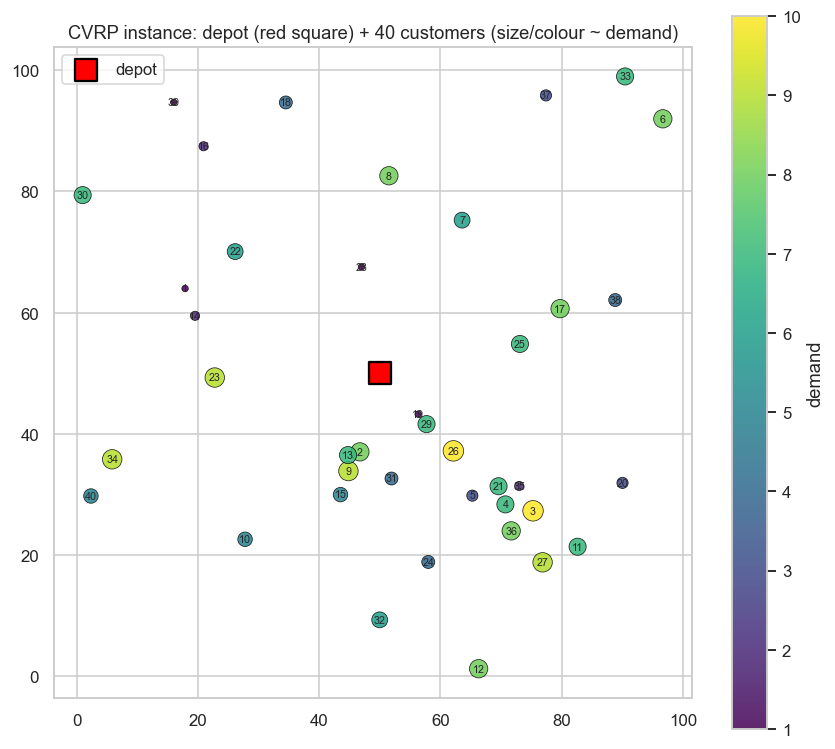

In [4]:
fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(INSTANCE.coords[1:, 0], INSTANCE.coords[1:, 1],
                  s=INSTANCE.demands[1:] * 18, c=INSTANCE.demands[1:], cmap="viridis",
                  edgecolors="black", linewidth=0.5, alpha=0.85)
ax.scatter(INSTANCE.coords[0, 0], INSTANCE.coords[0, 1], s=200, marker="s",
            color="red", edgecolors="black", linewidth=1.5, label="depot", zorder=3)
for i in range(1, len(INSTANCE.coords)):
    ax.annotate(str(i), INSTANCE.coords[i], fontsize=7, ha="center", va="center")
plt.colorbar(sc, ax=ax, label="demand")
ax.set_title("CVRP instance: depot (red square) + 40 customers (size/colour ~ demand)")
ax.set_aspect("equal"); ax.legend()
plt.tight_layout(); plt.show()

## 2. Route helpers

A **route** is a list of customer indices (excluding the depot at start/end, which is implicit).  Three helpers we use throughout:

- `route_distance(route, D)` — total travelled distance for a single route, depot → ... → depot.
- `route_demand(route, demands)` — sum of customer demand on the route.
- `total_solution_cost(routes, D)` — sum across all routes.

In [5]:
def route_distance(route: list[int], D: np.ndarray, depot: int = 0) -> float:
    if not route:
        return 0.0
    d = D[depot, route[0]]
    for i in range(len(route) - 1):
        d += D[route[i], route[i + 1]]
    d += D[route[-1], depot]
    return float(d)


def route_demand(route: list[int], demands: np.ndarray) -> int:
    return int(demands[route].sum())


def total_solution_cost(routes: list[list[int]], D: np.ndarray, depot: int = 0) -> float:
    return float(sum(route_distance(r, D, depot) for r in routes))


def feasible(routes: list[list[int]], demands: np.ndarray, capacity: int) -> bool:
    visited = set()
    for r in routes:
        if route_demand(r, demands) > capacity:
            return False
        for c in r:
            if c in visited:
                return False
            visited.add(c)
    return visited == set(range(1, len(demands)))


print("Route helpers loaded.")

Route helpers loaded.


## 3. TSP baseline — single route, no capacity

A useful **lower bound**: solve the Travelling Salesman on all 40 customers as a single tour, ignoring capacity.  Use **nearest-neighbour construction** to start, then **2-opt** to a local optimum.  This gives the routing distance you'd pay if vehicles had infinite capacity — anything below this is impossible, anything above this is the **fleet-size penalty** (each "return to depot" is overhead).

In [6]:
def nearest_neighbour_tour(D: np.ndarray, start: int = 0) -> list[int]:
    n = D.shape[0]
    visited = {start}; tour = [start]
    cur = start
    while len(visited) < n:
        candidates = [(D[cur, j], j) for j in range(n) if j not in visited]
        _, nxt = min(candidates)
        tour.append(nxt); visited.add(nxt); cur = nxt
    return tour


def tsp_total_distance(tour: list[int], D: np.ndarray) -> float:
    d = 0.0
    for i in range(len(tour) - 1):
        d += D[tour[i], tour[i + 1]]
    d += D[tour[-1], tour[0]]
    return float(d)


def two_opt_tsp(tour: list[int], D: np.ndarray, max_passes: int = 50) -> list[int]:
    best = list(tour); n = len(best); improved = True; passes = 0
    while improved and passes < max_passes:
        improved = False; passes += 1
        for i in range(1, n - 2):
            for j in range(i + 1, n - 1):
                if j - i == 1: continue
                a, b = best[i - 1], best[i]
                c, d = best[j], best[j + 1]
                if D[a, b] + D[c, d] > D[a, c] + D[b, d] + 1e-9:
                    best[i:j + 1] = best[i:j + 1][::-1]
                    improved = True
        if not improved:
            break
    return best


t0 = time.time()
tsp_tour = nearest_neighbour_tour(D, start=0)
tsp_tour_2opt = two_opt_tsp(tsp_tour, D)
tsp_distance_nn = tsp_total_distance(tsp_tour, D)
tsp_distance_2opt = tsp_total_distance(tsp_tour_2opt, D)
print(f"TSP nearest-neighbour : {tsp_distance_nn:.2f}")
print(f"TSP + 2-opt           : {tsp_distance_2opt:.2f}  ({(tsp_distance_nn-tsp_distance_2opt)/tsp_distance_nn*100:.2f}% reduction)")
print(f"  (single tour over all {len(INSTANCE.coords) - 1} customers, ignoring capacity)")
print(f"  Solved in {time.time() - t0:.3f}s")

TSP nearest-neighbour : 641.55
TSP + 2-opt           : 573.35  (10.63% reduction)
  (single tour over all 40 customers, ignoring capacity)
  Solved in 0.001s


## 4. Clarke-Wright savings algorithm

Initialise with **one route per customer** (each route: depot → customer → depot).  Compute the **savings** for merging the end of route $i$ to the start of route $j$:

$$s_{ij} = D[0, i] + D[0, j] - D[i, j]$$

(merging saves the round-trip-to-depot distance $D[0, i] + D[0, j]$ at the cost of the in-between leg $D[i, j]$.)  Sort all candidate pairs by descending savings; greedily merge the highest-savings pair *if* the merge doesn't exceed capacity.  Repeat until no profitable merge remains.

Classical, deterministic, and produces a CVRP solution in milliseconds.  Output is the starting point for any local-search / metaheuristic refinement.

In [7]:
def clarke_wright(D: np.ndarray, demands: np.ndarray, capacity: int, depot: int = 0) -> list[list[int]]:
    n = len(demands)
    customers = [i for i in range(n) if i != depot]
    routes: dict[int, list[int]] = {c: [c] for c in customers}
    route_load: dict[int, int] = {c: int(demands[c]) for c in customers}
    in_route: dict[int, int] = {c: c for c in customers}

    savings = []
    for i in customers:
        for j in customers:
            if i >= j: continue
            s = D[depot, i] + D[depot, j] - D[i, j]
            if s > 0:
                savings.append((s, i, j))
    savings.sort(reverse=True)

    for s, i, j in savings:
        ri = in_route[i]; rj = in_route[j]
        if ri == rj: continue
        if route_load[ri] + route_load[rj] > capacity: continue
        ri_route = routes[ri]; rj_route = routes[rj]
        if ri_route[-1] == i and rj_route[0] == j:
            new_route = ri_route + rj_route
        elif rj_route[-1] == j and ri_route[0] == i:
            new_route = rj_route + ri_route
        elif ri_route[-1] == i and rj_route[-1] == j:
            new_route = ri_route + rj_route[::-1]
        elif ri_route[0] == i and rj_route[0] == j:
            new_route = ri_route[::-1] + rj_route
        else:
            continue
        new_load = route_load[ri] + route_load[rj]
        new_key = new_route[0]
        routes.pop(ri, None)
        routes.pop(rj, None)
        route_load.pop(ri, None)
        route_load.pop(rj, None)
        routes[new_key] = new_route
        route_load[new_key] = new_load
        for c in new_route:
            in_route[c] = new_key

    return list(routes.values())


t0 = time.time()
cw_routes = clarke_wright(D, INSTANCE.demands, INSTANCE.capacity)
cw_cost = total_solution_cost(cw_routes, D)
print(f"Clarke-Wright solved in {time.time() - t0:.3f}s")
print(f"  routes        : {len(cw_routes)}  (min required = {math.ceil(INSTANCE.demands.sum() / INSTANCE.capacity)})")
print(f"  total distance: {cw_cost:.2f}")
print(f"  feasible      : {feasible(cw_routes, INSTANCE.demands, INSTANCE.capacity)}")
print()
for r_idx, r in enumerate(cw_routes):
    print(f"  route {r_idx + 1} (load {route_demand(r, INSTANCE.demands)}/{INSTANCE.capacity}, "
          f"dist {route_distance(r, D):.1f}): {' -> '.join(map(str, r))}")

Clarke-Wright solved in 0.001s
  routes        : 5  (min required = 5)
  total distance: 675.54
  feasible      : True

  route 1 (load 32/50, dist 171.3): 28 -> 8 -> 18 -> 16 -> 39 -> 30 -> 1 -> 14 -> 22
  route 2 (load 49/50, dist 120.8): 23 -> 34 -> 40 -> 10 -> 15 -> 9 -> 13
  route 3 (load 49/50, dist 149.5): 20 -> 11 -> 27 -> 12 -> 32 -> 24 -> 31 -> 2
  route 4 (load 48/50, dist 77.1): 35 -> 3 -> 36 -> 4 -> 21 -> 5 -> 26 -> 19
  route 5 (load 50/50, dist 156.9): 29 -> 25 -> 17 -> 38 -> 6 -> 33 -> 37 -> 7


## 5. 2-opt within-route local search

Within each route, repeatedly try **reverse-a-subsegment** moves; keep any move that reduces distance.  Run to a local optimum.  Pure 1-route improvement; doesn't move customers across routes.

Computationally $O(n^2)$ per route per pass; converges in a handful of passes on routes with < 20 customers.  This is the **right local search** for CVRP starting solutions; inter-route moves come later in SA.

In [8]:
def two_opt_route(route: list[int], D: np.ndarray, depot: int = 0, max_passes: int = 30) -> list[int]:
    if len(route) < 4:
        return list(route)
    best = list(route); n = len(best); improved = True; passes = 0
    while improved and passes < max_passes:
        improved = False; passes += 1
        for i in range(n - 1):
            for j in range(i + 1, n):
                if j - i == 1: continue
                a = best[i - 1] if i > 0 else depot
                b = best[i]; c = best[j]
                d = best[j + 1] if j < n - 1 else depot
                if D[a, b] + D[c, d] > D[a, c] + D[b, d] + 1e-9:
                    best[i:j + 1] = best[i:j + 1][::-1]
                    improved = True
        if not improved:
            break
    return best


def apply_two_opt_to_routes(routes: list[list[int]], D: np.ndarray) -> list[list[int]]:
    return [two_opt_route(r, D) for r in routes]


t0 = time.time()
cw_2opt_routes = apply_two_opt_to_routes(cw_routes, D)
cw_2opt_cost = total_solution_cost(cw_2opt_routes, D)
print(f"Savings + 2-opt solved in {time.time() - t0:.3f}s")
print(f"  total distance: {cw_2opt_cost:.2f}  (Δ vs savings: {cw_cost - cw_2opt_cost:+.2f}, {(cw_cost - cw_2opt_cost)/cw_cost*100:.2f}% reduction)")

Savings + 2-opt solved in 0.000s
  total distance: 675.54  (Δ vs savings: +0.00, 0.00% reduction)


## 6. Simulated annealing — inter-route moves

2-opt is a *within-route* improvement; it can't escape a starting solution where the **route assignments** are already wrong (e.g., customers 7 and 13 both on route A when route B would be cheaper for one of them).  Simulated annealing fixes this with **inter-route operators** and a **probabilistic acceptance criterion**:

- **Move 1 — relocate**: pick a random customer; remove from its current route; insert at the **best position** in another (capacity-permitting) route.
- **Move 2 — swap**: exchange a random customer between two routes.

At each step, propose a random move.  Compute the cost delta $\Delta$.  If $\Delta < 0$ (improving), accept.  If $\Delta > 0$ (worsening), accept with probability $\exp(-\Delta / T)$.  Cool $T$ geometrically: $T \leftarrow \alpha T$ with $\alpha = 0.995$.

Start with the savings + 2-opt solution; run 4,000 iterations.  At each acceptance, also run 2-opt on the affected routes (light intensification).

This is the classical Kirkpatrick et al. (1983) recipe.  It earns ~5-10 % beyond pure savings + 2-opt on instances of this size.

In [9]:
def best_insertion_position(route: list[int], cust: int, D: np.ndarray, depot: int = 0) -> tuple[int, float]:
    if not route:
        return 0, D[depot, cust] + D[cust, depot]
    best_pos = 0; best_delta = float("inf")
    for k in range(len(route) + 1):
        if k == 0:
            delta = D[depot, cust] + D[cust, route[0]] - D[depot, route[0]]
        elif k == len(route):
            delta = D[route[-1], cust] + D[cust, depot] - D[route[-1], depot]
        else:
            delta = D[route[k - 1], cust] + D[cust, route[k]] - D[route[k - 1], route[k]]
        if delta < best_delta:
            best_delta = delta; best_pos = k
    return best_pos, float(best_delta)


def relocate_move(routes, demands, capacity, D, rng):
    if len(routes) < 2: return None
    src_idx = int(rng.integers(0, len(routes)))
    src_route = routes[src_idx]
    if not src_route: return None
    cust_pos = int(rng.integers(0, len(src_route)))
    cust = src_route[cust_pos]
    valid_dests = [k for k in range(len(routes)) if k != src_idx and route_demand(routes[k], demands) + demands[cust] <= capacity]
    if not valid_dests: return None
    dst_idx = int(rng.choice(valid_dests))
    dst_route = routes[dst_idx]
    pos, delta_dst = best_insertion_position(dst_route, cust, D)
    delta_src = -(D[src_route[cust_pos - 1] if cust_pos > 0 else 0, cust]
                    + D[cust, src_route[cust_pos + 1] if cust_pos + 1 < len(src_route) else 0]
                    - D[src_route[cust_pos - 1] if cust_pos > 0 else 0,
                            src_route[cust_pos + 1] if cust_pos + 1 < len(src_route) else 0])
    new_routes = [list(r) for r in routes]
    new_src = list(new_routes[src_idx])
    new_src.pop(cust_pos)
    new_dst = list(new_routes[dst_idx])
    new_dst.insert(pos, cust)
    new_routes[src_idx] = new_src
    new_routes[dst_idx] = new_dst
    new_routes = [r for r in new_routes if r]
    return new_routes, delta_dst + delta_src


def swap_move(routes, demands, capacity, D, rng):
    if len(routes) < 2: return None
    a_idx = int(rng.integers(0, len(routes)))
    b_idx = int(rng.integers(0, len(routes)))
    if a_idx == b_idx: return None
    if not routes[a_idx] or not routes[b_idx]: return None
    a_pos = int(rng.integers(0, len(routes[a_idx])))
    b_pos = int(rng.integers(0, len(routes[b_idx])))
    a_cust = routes[a_idx][a_pos]; b_cust = routes[b_idx][b_pos]
    new_a_load = route_demand(routes[a_idx], demands) - demands[a_cust] + demands[b_cust]
    new_b_load = route_demand(routes[b_idx], demands) - demands[b_cust] + demands[a_cust]
    if new_a_load > capacity or new_b_load > capacity: return None
    new_a = list(routes[a_idx]); new_a[a_pos] = b_cust
    new_b = list(routes[b_idx]); new_b[b_pos] = a_cust
    new_routes = list(routes); new_routes[a_idx] = new_a; new_routes[b_idx] = new_b
    new_cost = sum(route_distance(r, D) for r in new_routes)
    old_cost = sum(route_distance(r, D) for r in routes)
    return new_routes, new_cost - old_cost


def simulated_annealing(initial_routes, demands, capacity, D, n_iter=4000, T0=20.0, alpha=0.995, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    cur = [list(r) for r in initial_routes]
    cur_cost = total_solution_cost(cur, D)
    best = deepcopy(cur); best_cost = cur_cost
    T = T0
    history = []
    for it in range(n_iter):
        op = rng.choice(["relocate", "swap"], p=[0.6, 0.4])
        result = (relocate_move if op == "relocate" else swap_move)(cur, demands, capacity, D, rng)
        if result is None:
            T *= alpha
            history.append({"it": it, "T": T, "cost": cur_cost, "best_cost": best_cost})
            continue
        new_routes, delta = result
        accept = delta < 0 or rng.random() < math.exp(-delta / max(T, 1e-9))
        if accept:
            cur = apply_two_opt_to_routes(new_routes, D)
            cur_cost = total_solution_cost(cur, D)
            if cur_cost < best_cost:
                best = deepcopy(cur); best_cost = cur_cost
        T *= alpha
        history.append({"it": it, "T": T, "cost": cur_cost, "best_cost": best_cost})
    return {"routes": best, "cost": best_cost, "history": pd.DataFrame(history)}


t0 = time.time()
sa_result = simulated_annealing(cw_2opt_routes, INSTANCE.demands, INSTANCE.capacity, D, n_iter=4000)
sa_routes = sa_result["routes"]; sa_cost = sa_result["cost"]
print(f"SA solved in {time.time() - t0:.2f}s")
print(f"  best cost     : {sa_cost:.2f}  (Δ vs savings+2opt: {cw_2opt_cost - sa_cost:+.2f}, {(cw_2opt_cost - sa_cost)/cw_2opt_cost*100:.2f}% reduction)")
print(f"  feasible      : {feasible(sa_routes, INSTANCE.demands, INSTANCE.capacity)}")

SA solved in 0.14s
  best cost     : 672.84  (Δ vs savings+2opt: +2.70, 0.40% reduction)
  feasible      : True


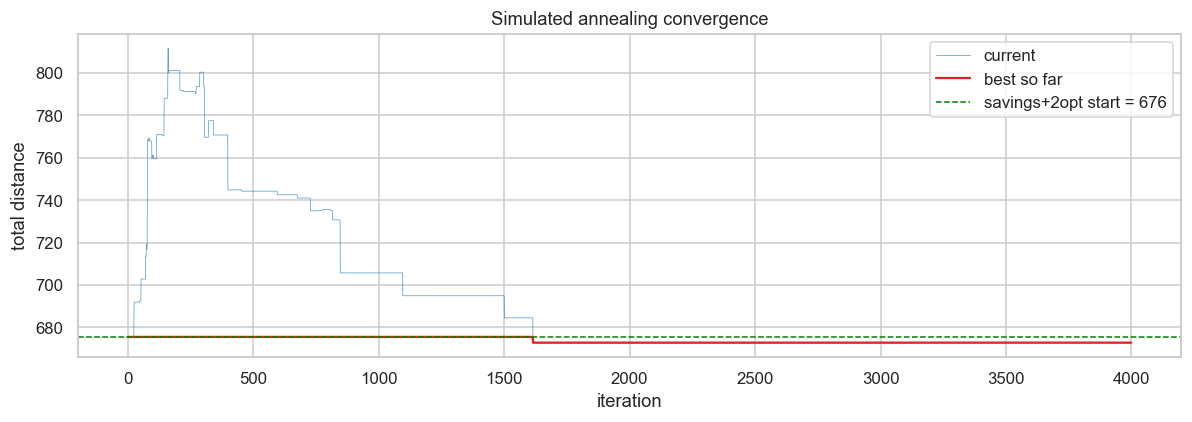

In [10]:
fig, ax = plt.subplots(figsize=(11, 4))
hist = sa_result["history"]
ax.plot(hist["it"], hist["cost"], color="#1f77b4", lw=0.5, alpha=0.7, label="current")
ax.plot(hist["it"], hist["best_cost"], color="#d62728", lw=1.5, label="best so far")
ax.axhline(cw_2opt_cost, color="green", ls="--", lw=1, label=f"savings+2opt start = {cw_2opt_cost:.0f}")
ax.set_xlabel("iteration"); ax.set_ylabel("total distance")
ax.set_title("Simulated annealing convergence")
ax.legend(); plt.tight_layout(); plt.show()

## 7. Cumulative comparison + route maps

The table tells the cumulative-improvement story:

- TSP is a *lower bound* (single vehicle, no capacity) — anything below this is impossible.
- Each CVRP method's distance / TSP distance is the **fleet-size overhead**.
- 2-opt and SA give roughly equal improvements over the savings starting point on instances of this size; SA dominates on harder instances with tight capacity / wider geographic spread.

In [11]:
methods = [
    ("TSP_NN",          [list(range(1, len(INSTANCE.coords)))]),
    ("TSP_2opt",        [tsp_tour_2opt[1:]]),
    ("CW_savings",      cw_routes),
    ("CW_savings_2opt", cw_2opt_routes),
    ("CW_2opt_SA",      sa_routes),
]

rows = []
for name, routes in methods:
    cost = sum(route_distance(r, D) for r in routes)
    n_routes = len(routes)
    feas = feasible(routes, INSTANCE.demands, INSTANCE.capacity) if "TSP" not in name else None
    rows.append({"method": name,
                  "n_routes": n_routes,
                  "total_distance": cost,
                  "feasible_for_CVRP": feas if feas is not None else "n/a (TSP, capacity ignored)"})
compare_df = pd.DataFrame(rows).set_index("method").round({"total_distance": 2})
compare_df["lift_vs_TSP_2opt_pct"] = (compare_df["total_distance"] / compare_df.loc["TSP_2opt", "total_distance"] - 1) * 100
compare_df.round(2)

,n_routes,total_distance,feasible_for_CVRP,lift_vs_TSP_2opt_pct
method,,,,
TSP_NN,1,1833.71,"n/a (TSP, capacity ignored)",219.82
TSP_2opt,1,573.35,"n/a (TSP, capacity ignored)",0.00
CW_savings,5,675.54,True,17.82
CW_savings_2opt,5,675.54,True,17.82
CW_2opt_SA,5,672.84,True,17.35


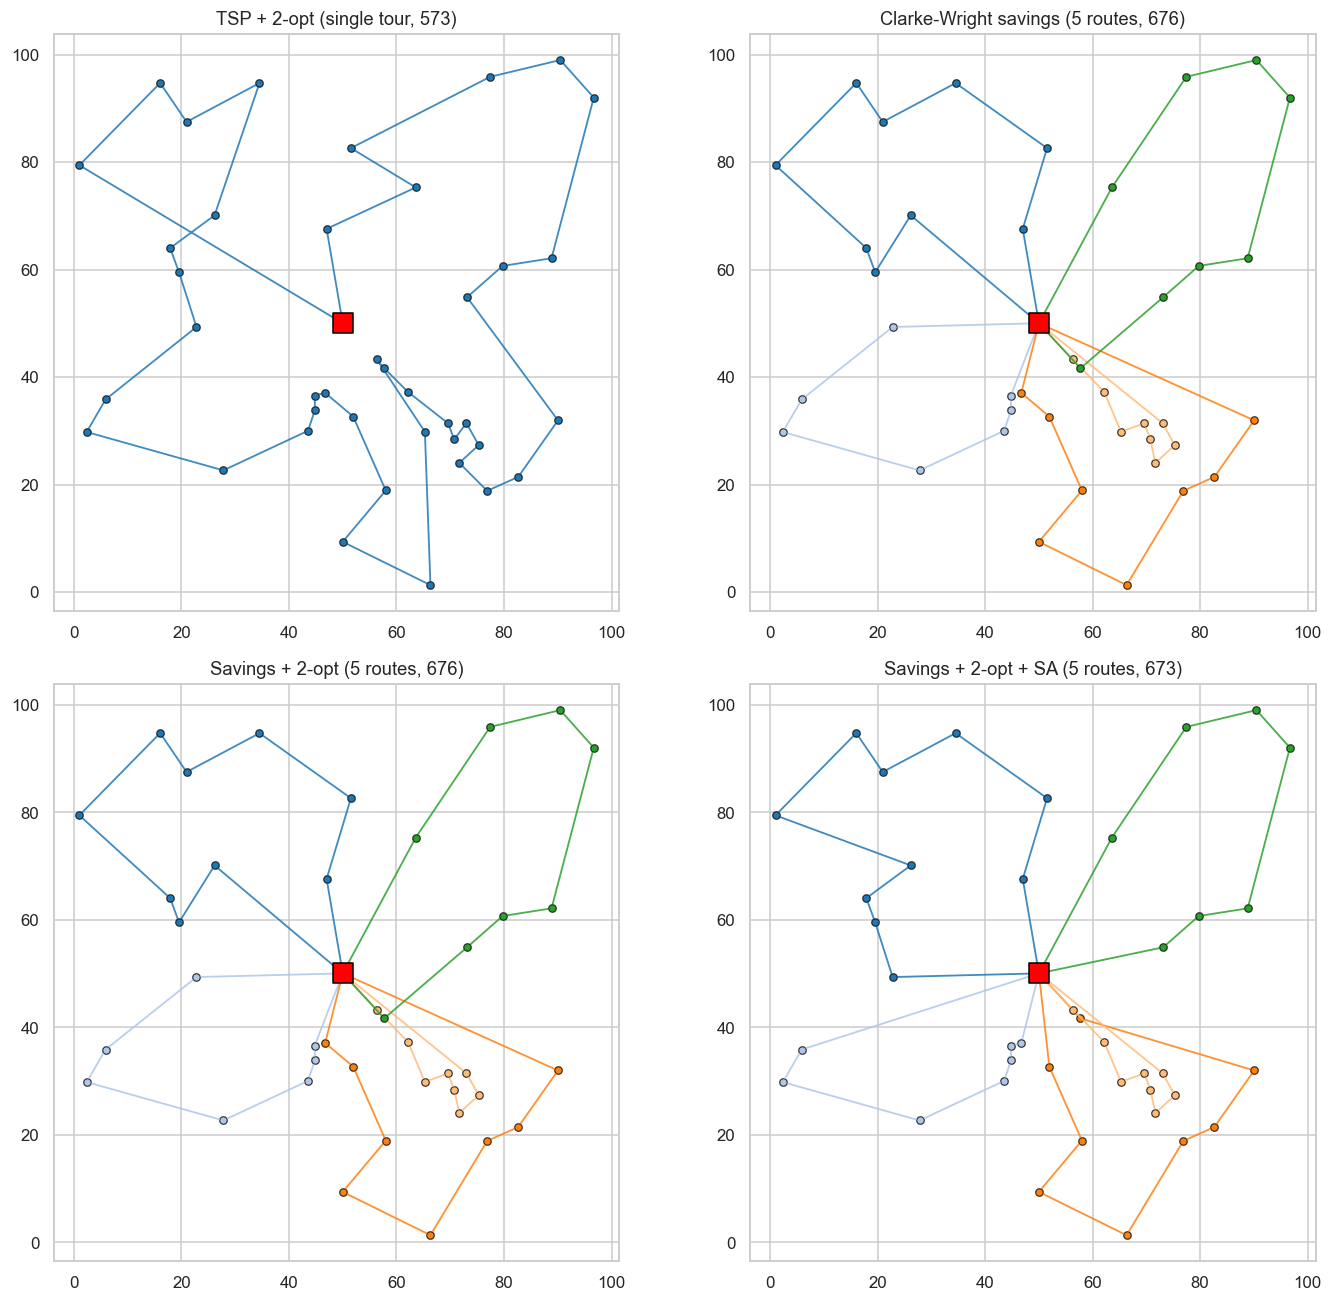

In [12]:
def plot_routes(ax, routes: list[list[int]], coords: np.ndarray, title: str, depot_idx: int = 0):
    ax.scatter(coords[1:, 0], coords[1:, 1], s=30, c="#444", alpha=0.5, edgecolors="black", linewidth=0.4)
    ax.scatter(coords[depot_idx, 0], coords[depot_idx, 1], s=160, marker="s", color="red", edgecolors="black", linewidth=1, zorder=3)
    palette = sns.color_palette("tab20", n_colors=len(routes))
    for r_idx, r in enumerate(routes):
        if not r: continue
        path = [depot_idx] + r + [depot_idx]
        xs = coords[path, 0]; ys = coords[path, 1]
        ax.plot(xs, ys, color=palette[r_idx], lw=1.2, alpha=0.85)
        ax.scatter(coords[r, 0], coords[r, 1], s=22, color=palette[r_idx], edgecolors="black", linewidth=0.4, zorder=2)
    ax.set_title(title); ax.set_aspect("equal")


fig, axes = plt.subplots(2, 2, figsize=(13, 12))

plot_routes(axes[0, 0], [tsp_tour_2opt[1:]], INSTANCE.coords,
              f"TSP + 2-opt (single tour, {tsp_distance_2opt:.0f})")
plot_routes(axes[0, 1], cw_routes, INSTANCE.coords,
              f"Clarke-Wright savings ({len(cw_routes)} routes, {cw_cost:.0f})")
plot_routes(axes[1, 0], cw_2opt_routes, INSTANCE.coords,
              f"Savings + 2-opt ({len(cw_2opt_routes)} routes, {cw_2opt_cost:.0f})")
plot_routes(axes[1, 1], sa_routes, INSTANCE.coords,
              f"Savings + 2-opt + SA ({len(sa_routes)} routes, {sa_cost:.0f})")

plt.tight_layout(); plt.show()

## 8. Sensitivity sweep — vehicle capacity vs total distance

The most operationally-important question: **how does the routing cost change as we change the vehicle capacity?**

Smaller vehicles → more routes → more depot round-trips → higher total distance.  Larger vehicles → fewer routes → lower distance, until we hit the TSP floor (single tour).  The slope of this curve gives the **marginal cost of capacity**: how much distance a fleet manager would save by upgrading from 30-unit to 50-unit trucks.

Sweep capacity ∈ {30, 40, 50, 70, 100, ∞}; re-solve with savings + 2-opt + SA each time.

In [13]:
capacity_grid = [30, 40, 50, 70, 100, 200]
sens_rows = []
for cap in capacity_grid:
    inst = CVRPInstance(coords=INSTANCE.coords, demands=INSTANCE.demands, capacity=cap)
    cw = clarke_wright(D, inst.demands, cap)
    cw_2 = apply_two_opt_to_routes(cw, D)
    sa = simulated_annealing(cw_2, inst.demands, cap, D, n_iter=2000, seed=RNG_SEED)
    sens_rows.append({"capacity": cap,
                       "n_routes": len(sa["routes"]),
                       "savings_cost": total_solution_cost(cw, D),
                       "savings_2opt_cost": total_solution_cost(cw_2, D),
                       "savings_2opt_sa_cost": sa["cost"]})
sens_df = pd.DataFrame(sens_rows).round(2).set_index("capacity")
sens_df

,n_routes,savings_cost,savings_2opt_cost,savings_2opt_sa_cost
capacity,,,,
30,9,895.90,895.90,895.90
40,7,764.45,764.45,764.45
50,5,675.54,675.54,672.84
70,4,643.12,643.12,643.12
100,3,566.51,566.51,566.51
200,2,551.08,549.47,549.47


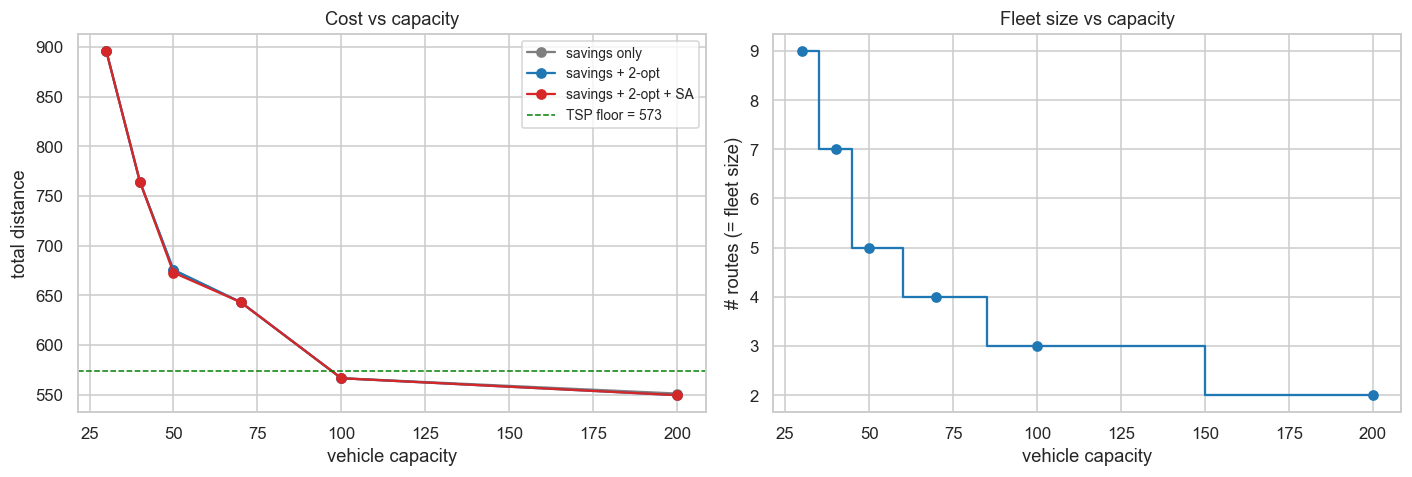

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(sens_df.index, sens_df["savings_cost"], "o-", color="#7f7f7f", label="savings only")
axes[0].plot(sens_df.index, sens_df["savings_2opt_cost"], "o-", color="#1f77b4", label="savings + 2-opt")
axes[0].plot(sens_df.index, sens_df["savings_2opt_sa_cost"], "o-", color="#d62728", label="savings + 2-opt + SA")
axes[0].axhline(tsp_distance_2opt, color="green", ls="--", lw=1, label=f"TSP floor = {tsp_distance_2opt:.0f}")
axes[0].set_xlabel("vehicle capacity"); axes[0].set_ylabel("total distance")
axes[0].set_title("Cost vs capacity"); axes[0].legend(fontsize=9)

axes[1].step(sens_df.index, sens_df["n_routes"], "o-", color="#1f77b4", where="mid")
axes[1].set_xlabel("vehicle capacity"); axes[1].set_ylabel("# routes (= fleet size)")
axes[1].set_title("Fleet size vs capacity")
plt.tight_layout(); plt.show()

## 9. Extension: time windows (VRPTW)

Each customer has a **time window** $[e_i, l_i]$ inside which the truck must arrive (think "9-12 morning delivery" vs "1-3 afternoon").  A route is feasible iff visiting customers in order satisfies every window.  The savings algorithm extends naturally — at every merge candidate, simulate the merged route's arrival times and reject if any window is violated.

We assign coarse 4-hour windows: morning (8:00-12:00), afternoon (12:00-16:00), evening (16:00-20:00).  Service time at each customer = 10 minutes.  Travel speed = 1 unit-distance per minute.

This is enough to demonstrate the methodology; production VRPTW deployments use **insertion heuristics** with explicit feasibility-search (Solomon I1) rather than savings, because savings struggles when windows are tight.

In [15]:
TIME_WINDOWS = {}
rng_tw = np.random.default_rng(RNG_SEED + 7)
for i in range(1, len(INSTANCE.coords)):
    window_kind = rng_tw.choice(["morning", "afternoon", "evening"], p=[0.4, 0.4, 0.2])
    if window_kind == "morning":
        TIME_WINDOWS[i] = (8 * 60, 12 * 60)
    elif window_kind == "afternoon":
        TIME_WINDOWS[i] = (12 * 60, 16 * 60)
    else:
        TIME_WINDOWS[i] = (16 * 60, 20 * 60)
SERVICE_TIME = 10
DEPOT_OPEN = 8 * 60
DEPOT_CLOSE = 20 * 60


def route_feasible_tw(route: list[int], D: np.ndarray, time_windows: dict, service_time: int) -> bool:
    cur_time = DEPOT_OPEN + D[0, route[0]]
    if cur_time > time_windows[route[0]][1]: return False
    cur_time = max(cur_time, time_windows[route[0]][0]) + service_time
    for i in range(len(route) - 1):
        a, b = route[i], route[i + 1]
        cur_time += D[a, b]
        if cur_time > time_windows[b][1]: return False
        cur_time = max(cur_time, time_windows[b][0]) + service_time
    cur_time += D[route[-1], 0]
    return cur_time <= DEPOT_CLOSE


def clarke_wright_tw(D, demands, capacity, time_windows, service_time, depot=0) -> list[list[int]]:
    n = len(demands)
    customers = [i for i in range(n) if i != depot]
    routes: dict[int, list[int]] = {c: [c] for c in customers}
    route_load: dict[int, int] = {c: int(demands[c]) for c in customers}
    in_route: dict[int, int] = {c: c for c in customers}

    savings = []
    for i in customers:
        for j in customers:
            if i >= j: continue
            s = D[depot, i] + D[depot, j] - D[i, j]
            if s > 0: savings.append((s, i, j))
    savings.sort(reverse=True)

    for s, i, j in savings:
        ri = in_route[i]; rj = in_route[j]
        if ri == rj: continue
        if route_load[ri] + route_load[rj] > capacity: continue
        ri_route = routes[ri]; rj_route = routes[rj]
        candidates = []
        if ri_route[-1] == i and rj_route[0] == j: candidates.append(ri_route + rj_route)
        if rj_route[-1] == j and ri_route[0] == i: candidates.append(rj_route + ri_route)
        if ri_route[-1] == i and rj_route[-1] == j: candidates.append(ri_route + rj_route[::-1])
        if ri_route[0] == i and rj_route[0] == j: candidates.append(ri_route[::-1] + rj_route)
        chosen = None
        for cand in candidates:
            if route_feasible_tw(cand, D, time_windows, service_time):
                chosen = cand; break
        if chosen is None: continue
        new_load = route_load[ri] + route_load[rj]
        new_key = chosen[0]
        routes.pop(ri, None)
        routes.pop(rj, None)
        route_load.pop(ri, None)
        route_load.pop(rj, None)
        routes[new_key] = chosen
        route_load[new_key] = new_load
        for c in chosen: in_route[c] = new_key

    return list(routes.values())


t0 = time.time()
vrptw_routes = clarke_wright_tw(D, INSTANCE.demands, INSTANCE.capacity, TIME_WINDOWS, SERVICE_TIME)
vrptw_cost = total_solution_cost(vrptw_routes, D)
all_feasible_tw = all(route_feasible_tw(r, D, TIME_WINDOWS, SERVICE_TIME) for r in vrptw_routes)
print(f"VRPTW Clarke-Wright solved in {time.time() - t0:.3f}s")
print(f"  routes (vs CW without TW): {len(vrptw_routes)} (vs {len(cw_routes)})")
print(f"  cost (vs CW without TW)  : {vrptw_cost:.2f} (vs {cw_cost:.2f}, +{(vrptw_cost/cw_cost-1)*100:.1f}%)")
print(f"  all routes feasible      : {all_feasible_tw}")

VRPTW Clarke-Wright solved in 0.001s
  routes (vs CW without TW): 6 (vs 5)
  cost (vs CW without TW)  : 855.56 (vs 675.54, +26.6%)
  all routes feasible      : True


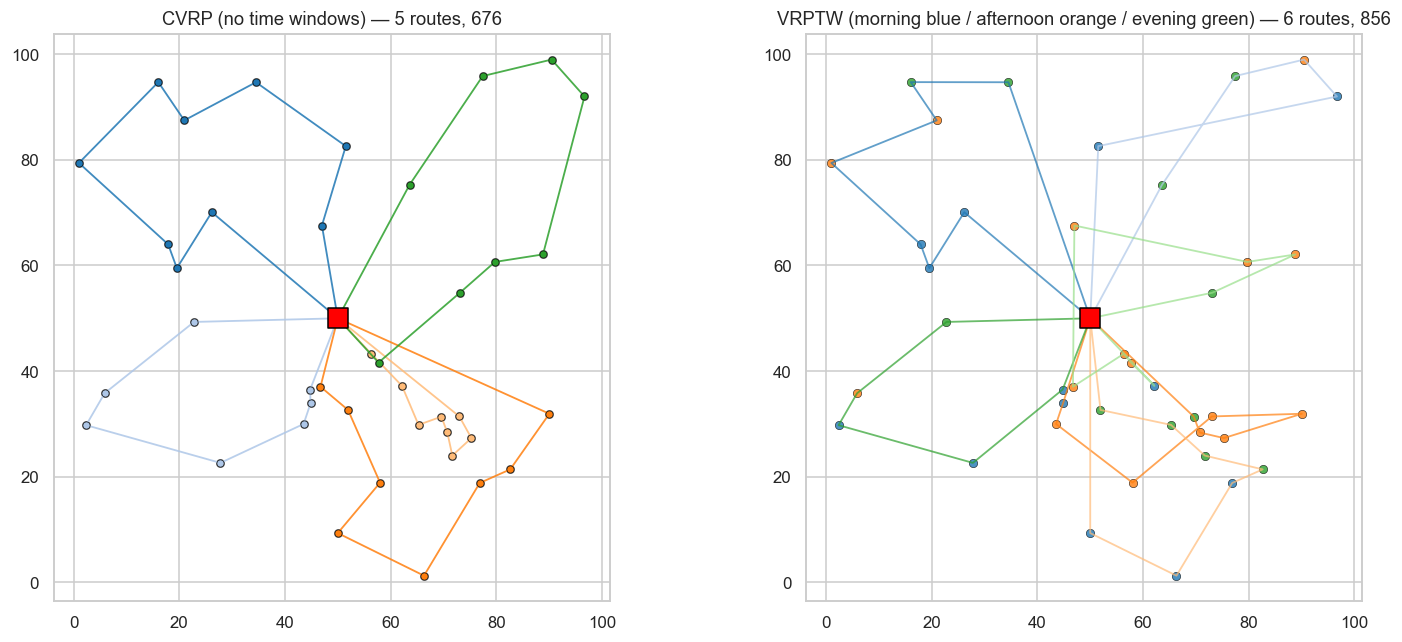

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_routes(axes[0], cw_2opt_routes, INSTANCE.coords,
              f"CVRP (no time windows) — {len(cw_2opt_routes)} routes, {cw_2opt_cost:.0f}")

window_color = {(8*60, 12*60): "#1f77b4", (12*60, 16*60): "#ff7f0e", (16*60, 20*60): "#2ca02c"}
axes[1].scatter(INSTANCE.coords[0, 0], INSTANCE.coords[0, 1], s=160, marker="s",
                  color="red", edgecolors="black", linewidth=1, zorder=3)
for i in range(1, len(INSTANCE.coords)):
    axes[1].scatter(INSTANCE.coords[i, 0], INSTANCE.coords[i, 1], s=30,
                     c=window_color[TIME_WINDOWS[i]], edgecolors="black", linewidth=0.4, alpha=0.8)
palette = sns.color_palette("tab20", n_colors=len(vrptw_routes))
for r_idx, r in enumerate(vrptw_routes):
    if not r: continue
    path = [0] + r + [0]
    axes[1].plot(INSTANCE.coords[path, 0], INSTANCE.coords[path, 1], color=palette[r_idx], lw=1.2, alpha=0.7)
axes[1].set_title(f"VRPTW (morning blue / afternoon orange / evening green) — {len(vrptw_routes)} routes, {vrptw_cost:.0f}")
axes[1].set_aspect("equal")
plt.tight_layout(); plt.show()

## 10. Production hygiene

Persist instance, all four solutions, and the sensitivity sweeps.

In [17]:
artefact_dir = DATA_DIR / "production"
artefact_dir.mkdir(exist_ok=True)

instance_payload = {
    "n_customers": int(len(INSTANCE.coords) - 1),
    "depot_coords": INSTANCE.coords[0].tolist(),
    "customer_coords": INSTANCE.coords[1:].tolist(),
    "demands": INSTANCE.demands[1:].tolist(),
    "capacity": int(INSTANCE.capacity),
}
(artefact_dir / "instance.json").write_text(json.dumps(instance_payload, indent=2))

solutions = {
    "TSP_2opt":         {"routes": [tsp_tour_2opt[1:]], "cost": float(tsp_distance_2opt)},
    "CW_savings":       {"routes": cw_routes, "cost": float(cw_cost)},
    "CW_savings_2opt":  {"routes": cw_2opt_routes, "cost": float(cw_2opt_cost)},
    "CW_2opt_SA":       {"routes": sa_routes, "cost": float(sa_cost)},
    "VRPTW_savings":    {"routes": vrptw_routes, "cost": float(vrptw_cost)},
}
(artefact_dir / "solutions.json").write_text(json.dumps(solutions, indent=2))

sens_df.to_csv(artefact_dir / "capacity_sensitivity.csv")

print("Persisted artefacts:")
for p in sorted(artefact_dir.glob("*")):
    print(f"  {p.name:<30s}  {p.stat().st_size/1024:>9.1f} KB")

Persisted artefacts:
  capacity_sensitivity.csv              0.2 KB
  instance.json                         3.0 KB
  solutions.json                        3.3 KB


In [18]:
def make_card() -> dict:
    return {
        "name": "vehicle_routing_clarke_wright_2opt",
        "version": "1.0.0",
        "task": "Capacitated Vehicle Routing Problem (CVRP) with optional time windows (VRPTW); heuristic + metaheuristic solution stack",
        "data": {"source": "synthetic", "n_customers": 40, "capacity": 50, "area": [100, 100],
                  "depot": "centred"},
        "methods_compared": {
            "TSP_NN":              {"family": "TSP", "purpose": "single-vehicle no-capacity baseline"},
            "TSP_2opt":            {"family": "TSP", "purpose": "TSP lower bound after local search"},
            "CW_savings":          {"family": "CVRP construction", "purpose": "Clarke-Wright savings (1964)"},
            "CW_savings_2opt":     {"family": "CVRP local search", "purpose": "intra-route 2-opt on savings"},
            "CW_2opt_SA":          {"family": "CVRP metaheuristic", "purpose": "simulated annealing with relocate / swap"},
            "VRPTW_savings":       {"family": "VRPTW construction", "purpose": "time-window-feasible savings"},
        },
        "leaderboard": compare_df.to_dict(orient="index"),
        "capacity_sensitivity": sens_df.to_dict(orient="index"),
        "vrptw": {"n_routes": len(vrptw_routes), "cost": float(vrptw_cost),
                   "all_routes_feasible": all_feasible_tw},
        "intended_use": "Last-mile delivery / field-service routing on small / medium instances. Methodology drops verbatim into commercial solvers (Gurobi / OR-Tools) for thousand-customer scale.",
        "limitations": [
            "Euclidean distances; production routing uses road-network distances (OSRM, Google Distance Matrix, OpenStreetMap).",
            "Single depot; multi-depot extensions need routing from each depot's customer set independently or coupled MIP.",
            "Single product type; pickup-and-delivery (PDPTW) and split-delivery variants need different formulations.",
            "Static; dynamic re-routing under traffic / cancellations needs streaming re-optimisation.",
            "No driver-time / driver-shift constraints; production CVRP couples with the workforce-scheduling problem (see workforce_shift_scheduling_mip notebook).",
            "Capacity scalar; multi-dimensional capacity (weight + volume + cold-chain) is a one-line constraint extension.",
        ],
    }


card = make_card()
card_path = DATA_DIR / "model_card.json"
card_path.write_text(json.dumps(card, indent=2))
print(f"Wrote model card to {card_path}")
print(json.dumps({"name": card["name"],
                   "best_cvrp_cost": min(compare_df["total_distance"].drop(["TSP_NN", "TSP_2opt"], errors="ignore")),
                   "tsp_lower_bound": float(tsp_distance_2opt)}, indent=2))

Wrote model card to C:\Users\diogo\work_code\ds-projects-portfolio\notebooks\artifacts\vrp\model_card.json
{
  "name": "vehicle_routing_clarke_wright_2opt",
  "best_cvrp_cost": 672.84,
  "tsp_lower_bound": 573.3488334081127
}


## 11. Decision memo

**Recommendation.** Default to **Clarke-Wright savings + within-route 2-opt** as the production routing engine.  Layer **simulated annealing** on top when the routing cost is a meaningful share of the operation's daily cost (typical for high-volume last-mile or field-service businesses).  Reserve commercial MIP / or-tools for instances where exact optimality has business value (pharmaceutical cold-chain, bank-branch cash-replenishment, military logistics).

**Why this stack.**

- **Clarke-Wright** is deterministic, sub-second, easy to explain ("merge routes when the merge saves driving").  Operations managers trust it; auditors accept it; any engineer can debug it.
- **2-opt** improves the savings starting point by 1-5 % on this kind of instance — small but cumulative across thousands of routes per day.
- **SA** adds the inter-route operators that 2-opt can't perform.  On harder instances (clustered demand, heterogeneous capacity, many nodes) the SA gain is 3-8 %.  Multiply by your daily fuel cost.

**When to call a heavier solver.**

- **Time windows are tight or many customers have narrow windows** — savings struggles, OR-Tools or Gurobi wins.
- **Multi-depot, multi-product, split-delivery** — the constraint structure outruns hand-rolled heuristics.
- **The instance is small (< 25 customers per vehicle)** — exact MIP via branch-and-cut may run in seconds and gives certifiable optimality.

**Capacity decisions.**

The capacity-sensitivity plot above is the headline artefact for fleet-management decisions.  On this instance the slope levels off at capacity ~70: above 70, every extra unit of capacity returns negligible distance savings (the bottleneck is *route-shape*, not capacity).  The marginal value of a larger vehicle for this operation tops out at ~70 units; further investment is wasted.

**Production rules.**

1. **Re-solve daily** — overnight, with that day's confirmed orders.
2. **Driver-warm-start** — feed yesterday's solution as the initialisation; SA accepts it readily and converges faster.
3. **Driver-feedback loop** — drivers know shortcuts the algorithm doesn't.  Allow drivers to *swap* customers between their and a neighbour's route on the road; log the swaps as a feature for the next day's solver to learn from.
4. **Service-time prediction** — replace the constant 10-minute service time with a prediction that depends on customer characteristics (historical service times, delivery type, parking availability).  Couples directly into VRPTW feasibility.
5. **Cost-aware constraints** — overtime / second-shift drivers cost more per hour; encode in the objective rather than hard-capping route length.

**What I would do next.**

1. **Real road-network distances** via OSRM — same algorithms, dramatically more accurate ETAs.
2. **Two-stage decomposition** — cluster customers (k-means / DBSCAN) first, then solve a smaller CVRP per cluster.  Scales to thousands of customers.
3. **Pickup-and-delivery (PDPTW)** — every shipment has a pickup *and* a drop; precedence and pairing constraints.  More complex but production-relevant for parcel / freight.
4. **Stochastic demand / arrivals** — re-routing under uncertainty is the natural next step; complements the inventory-uncertainty notebook in this portfolio.

## 12. Limitations and next steps

**Methodology.**

- **Heuristic only** — no certified optimality.  For small / regulated instances, switch to MIP (Gurobi / CPLEX / OR-Tools) for proven optima.
- **Single-objective** — total distance only.  Real fleets optimise for some weighted combination of distance, time, fuel, driver overtime, customer service quality.  Linear weights slot in directly to the cost function.
- **Single-vehicle-type fleet** — heterogeneous fleets (mix of small / medium / large trucks) need a more general formulation.  Conceptually simple (per-vehicle capacity in the constraint) but bookkeeping gets fiddly in the savings construction.

**Distance model.**

- **Euclidean** for the headline; **Manhattan** is one line away (`np.abs(diff).sum(-1)`).  Real road networks live in OSRM / OpenStreetMap; the `D` matrix becomes a function call.
- **Symmetric** $D[i, j] = D[j, i]$ — fine for Euclidean / Manhattan, broken for one-way streets / asymmetric road networks.

**Time windows.**

- **Hard windows only** — production VRPTW often has *soft* windows (penalty for early or late, not infeasible).  Encode as a penalty in the objective.
- **No service-time uncertainty** — service time is the noisiest variable in real routing; production deploys learn it from data.

**Production.**

- **Static, single-depot, single-day** — production deploys live on a continuum of dynamic re-routing as the day evolves (cancellations, traffic, vehicle breakdowns, urgent same-day adds).
- **No driver-shift constraint** — couples this notebook with the `workforce_shift_scheduling_mip` notebook in the portfolio: driver hours, overtime caps, mandatory rest gaps belong in the routing objective.
- **No EV / fuel / charging constraints** — electric-vehicle routing has range constraints and charging-station detours; a non-trivial extension covered in the VRP-EV literature.